In [26]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import sqlite3


df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Dataset Shape : ", df.shape)
df.head()

Dataset Shape :  (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Attrition'].value_counts()         

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [ ]:
df['Attrition'].value_counts(normalize=True)*100
# how many out off 100 employees left the company in percentage

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [9]:
print("Total Employees: ", len(df))
print("Employees Left: ", (df['Attrition'] == "Yes").sum())
print("Employees Stayed: ", (df['Attrition'] == "No").sum())
print("Attrition Rate: ", round((df['Attrition'] == "Yes").mean()*100, 2), "%")


Total Employees:  1470
Employees Left:  237
Employees Stayed:  1233
Attrition Rate:  16.12 %


In [ ]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize="index"
)*100

department_attrition.round(2)         # check attrition from each department 

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


In [ ]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize="index"
)*100

overtime_attrition.round(2)        # check attrition by overtime 

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


In [13]:
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize="index"
)*100

jobrole_attrition.round(2)     # check attrition by jobrole

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.13,6.87
Human Resources,76.92,23.08
Laboratory Technician,76.06,23.94
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.52,17.48
Sales Representative,60.24,39.76


In [14]:
age_attrition = pd.crosstab(
    df['Age'],
    df['Attrition'],
    normalize="index"
)*100

age_attrition.round(2)

Attrition,No,Yes
Age,,
18,50.00,50.00
19,33.33,66.67
20,45.45,54.55
21,53.85,46.15
22,68.75,31.25
23,71.43,28.57
24,73.08,26.92
25,76.92,23.08
26,69.23,30.77


In [15]:
df["AgeGroup"] = pd.cut(
    df['Age'],
    bins= [17, 25, 35, 45, 55, 65],
    labels= ["18-25", "26-35", "36-45", "46-55", "56-65"]
)

agegroup_attrition = pd.crosstab(
    df['AgeGroup'],
    df['Attrition'],
    normalize='index'
) *100

agegroup_attrition.round(2)

Attrition,No,Yes
AgeGroup,,
18-25,64.23,35.77
26-35,80.86,19.14
36-45,90.81,9.19
46-55,88.50,11.50
56-65,82.98,17.02


In [ ]:
salary_attrition = df.groupby('Attrition')['MonthlyIncome'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

salary_attrition                    # check attrition based on salary 

,mean,median,min,max
Attrition,,,,
No,6832.74,5204.0,1051,19999
Yes,4787.09,3202.0,1009,19859


In [20]:
tenure_attrition = pd.crosstab(
    df['YearsAtCompany'],
    df['Attrition'],
    normalize='index'
)*100

tenure_attrition.round(3)

Attrition,No,Yes
YearsAtCompany,,
0,63.636,36.364
1,65.497,34.503
2,78.740,21.260
3,84.375,15.625
4,82.727,17.273
5,89.286,10.714
6,88.158,11.842
7,87.778,12.222
8,88.750,11.250


In [21]:
df['tentureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 20, 40],
    labels=['0-2 Year', '3-5 Year', '6-10 Year', '11-20 Year', '21-40 Year']
)

tentureGroup_attrition = pd.crosstab(
    df['tentureGroup'],
    df['Attrition'],
    normalize='index'
)*100

tentureGroup_attrition.round(2)

Attrition,No,Yes
tentureGroup,,
0-2 Year,70.18,29.82
3-5 Year,86.18,13.82
6-10 Year,87.72,12.28
11-20 Year,93.33,6.67
21-40 Year,87.88,12.12


In [22]:
jobsatisfaction_attrition = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
)*100

jobsatisfaction_attrition.round(2)

Attrition,No,Yes
JobSatisfaction,,
1,77.16,22.84
2,83.57,16.43
3,83.48,16.52
4,88.67,11.33


In [23]:
worklifebalance_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
)*100

worklifebalance_attrition.round(2)

Attrition,No,Yes
WorkLifeBalance,,
1,68.75,31.25
2,83.14,16.86
3,85.78,14.22
4,82.35,17.65


In [25]:
# OverAll insighst from above data calculations

insights = {
    "Overall Attrition": 16.12,
    "Sales Department": 20.63,
    "Overtime = Yes": 30.53,
    "Age 18-25": 35.77,
    "Sales Representative": 39.76,
    "Tenure 0-2 Years": 29.82,
    "Job Satisfaction = 1": 22.84,
    "Work-Life Balance = 1": 31.25
}

pd.Series(insights, name="Attrition Rate (%)").round(2)

Overall Attrition        16.12
Sales Department         20.63
Overtime = Yes           30.53
Age 18-25                35.77
Sales Representative     39.76
Tenure 0-2 Years         29.82
Job Satisfaction = 1     22.84
Work-Life Balance = 1    31.25
Name: Attrition Rate (%), dtype: float64

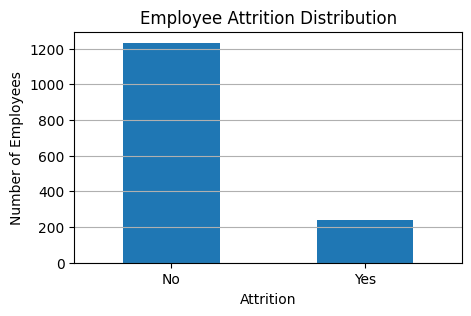

In [30]:
plt.figure(figsize=(5, 3))

df['Attrition'].value_counts().plot(
    kind='bar'
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

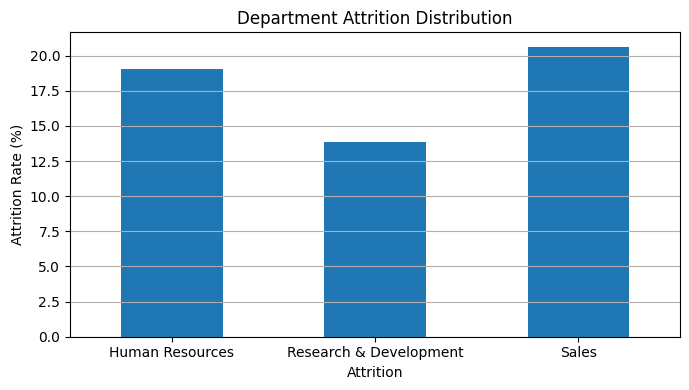

In [34]:
plt.figure(figsize=(7, 4))

department_attrition["Yes"].plot(
    kind='bar'
)

plt.title("Department Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

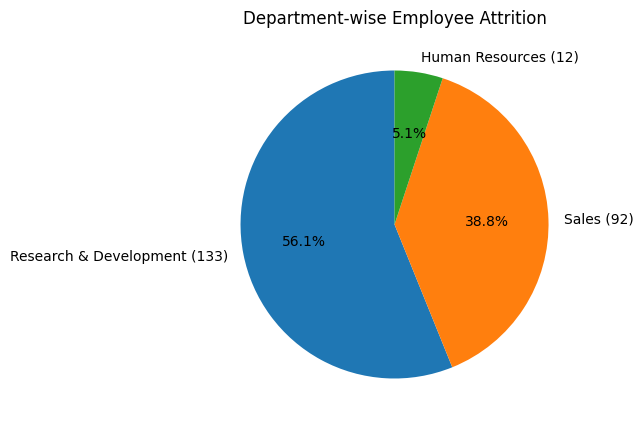

In [ ]:
department_left = df[df["Attrition"]=="Yes"]["Department"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    department_left.values,
    labels=[
        f"{dept} ({count})"
        for dept, count in department_left.items()
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Department-wise Employee Attrition")
plt.show()

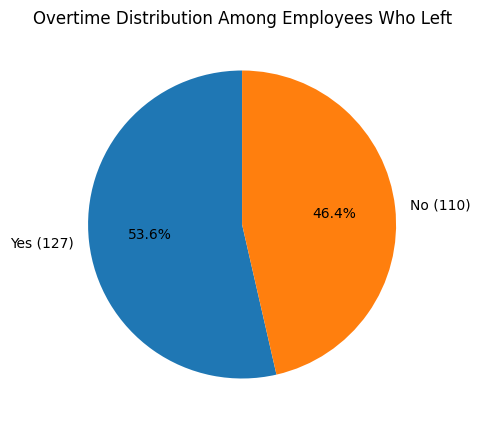

In [45]:
overtime_left = df[df['Attrition']=="Yes"]["OverTime"].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    overtime_left.values,
    labels = [
        f"{overt} ({count})"
        for overt, count in overtime_left.items()
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overtime Distribution Among Employees Who Left")
plt.show()

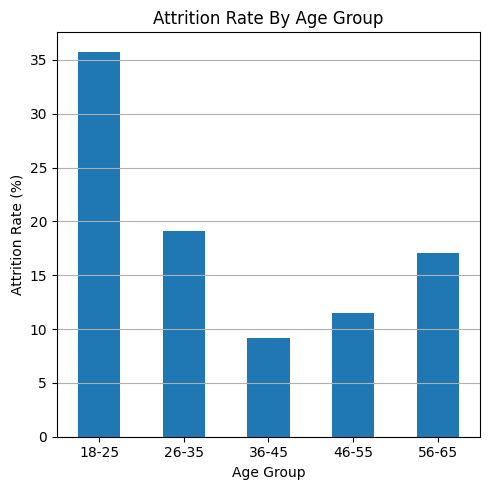

In [47]:
plt.figure(figsize=(5, 5))

agegroup_attrition["Yes"].plot(
    kind='bar'
)

plt.title("Attrition Rate By Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

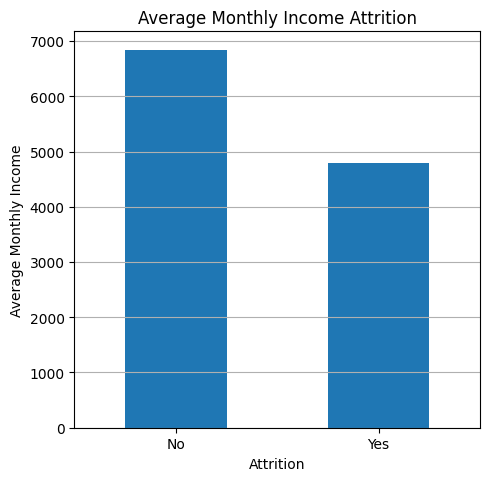

In [49]:
salary_mean = df.groupby("Attrition")["MonthlyIncome"].mean()

plt.figure(figsize=(5, 5))

salary_mean.plot(kind='bar')

plt.title("Average Monthly Income Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Monthly Income")
plt.grid(axis='y')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

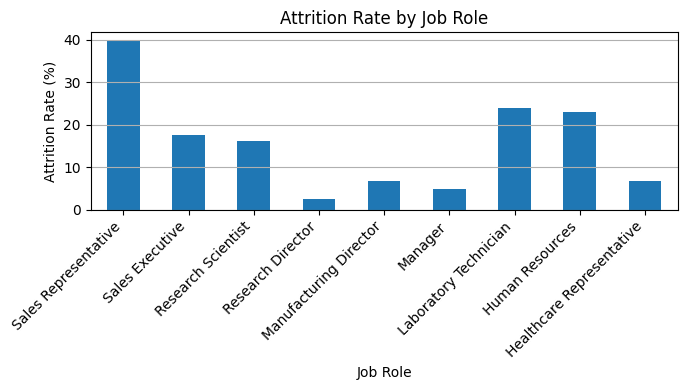

In [53]:
jobrole_rate = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean()*100)
    .sort_index(ascending=False)
)

plt.figure(figsize=(7, 4))

jobrole_rate.plot(kind='bar')

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

<Figure size 500x500 with 0 Axes>

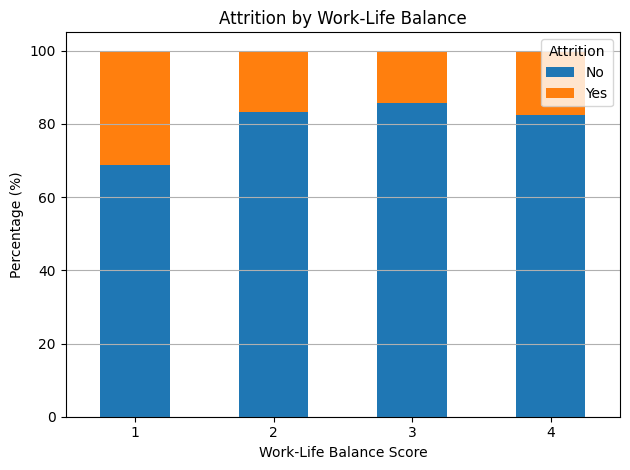

In [58]:
plt.figure(figsize=(5, 5))

worklifebalance_attrition.plot(
    kind='bar',
    stacked=True
)

plt.title("Attrition by Work-Life Balance")
plt.xlabel("Work-Life Balance Score")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [59]:
conn = sqlite3.connect("HR_Attrition_Analysis.db")

df.to_sql(
    "employees",
    conn, 
    if_exists="replace",
    index=False
)

print("Database Created Successfully")

Database Created Successfully


In [61]:
query = """ 
    SELECT 
        Department, COUNT(*) AS Total_Employees,
        SUM(CASE
            WHEN Attrition = 'Yes' THEN 1 ELSE 0
            END ) AS Employees_Left
    FROM employees
    GROUP BY Department
    ORDER BY Employees_Left DESC;

"""

department_sql = pd.read_sql(query, conn)
department_sql

,Department,Total_Employees,Employees_Left
0,Research & Development,961,133
1,Sales,446,92
2,Human Resources,63,12


In [62]:
query = """ 
    SELECT OverTime, COUNt(*) as Total_Employees,
    SUM(CASE
        WHEN Attrition = 'Yes' THEN 1 ELSE 0 END
    )AS Employees_Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)/COUNT(*), 2
    )AS Attrition_Rate
    FROM employees
    GROUP BY OverTime
    ORDER BY Attrition_Rate DESC;

"""

overtime_sql = pd.read_sql(query, conn)
overtime_sql

,OverTime,Total_Employees,Employees_Left,Attrition_Rate
0,Yes,416,127,30.53
1,No,1054,110,10.44


In [63]:
query = """ 
SELECT JobRole, COUNT(*) AS Total_employees, 
SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Employees_Left,
ROUND(
    100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)/COUNT(*), 2
    ) AS Attrition_Rate
FROM employees
GROUP BY JobRole
ORDER BY Attrition_Rate DESC;
"""

jobrole_sql = pd.read_sql(query, conn)
jobrole_sql

,JobRole,Total_employees,Employees_Left,Attrition_Rate
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10
5,Manufacturing Director,145,10,6.90
6,Healthcare Representative,131,9,6.87
7,Manager,102,5,4.90
8,Research Director,80,2,2.50


In [65]:
query = """ 
SELECT 
    CASE
        WHEN Age BETWEEN 18 AND 25 THEN '18-25'
        WHEN Age BETWEEN 26 AND 35 THEN '26-35'
        WHEN Age BETWEEN 36 AND 45 THEN '36-45'
        WHEN Age BETWEEN 46 AND 55 THEN '46-55'
        WHEN Age BETWEEN 56 AND 65 THEN '56-65'
    END as Age_Group,
    COUNT(*) AS Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Employees_Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)/COUNT(*), 2
        ) AS Attrition_Rate
    FROM employees
    GROUP BY Age_Group
    ORDER BY Attrition_Rate DESC;
        
"""

age_sql = pd.read_sql(query, conn)
age_sql

,Age_Group,Total_Employees,Employees_Left,Attrition_Rate
0,18-25,123,44,35.77
1,26-35,606,116,19.14
2,56-65,47,8,17.02
3,46-55,226,26,11.50
4,36-45,468,43,9.19


In [66]:
query = """ 
    SELECT Attrition, COUNT(*) As Total_Employees, 
    ROUND(AVG(MonthlyIncome), 2) As Average_Monthly_Income,
    MIN(MonthlyIncome) AS Minimum_Income,
    MAX(MonthlyIncome) AS Maximum_Income
    FROM employees
    GROUP BY Attrition
    ORDER BY Attrition;
"""

salary_sql = pd.read_sql(query, conn)
salary_sql

,Attrition,Total_Employees,Average_Monthly_Income,Minimum_Income,Maximum_Income
0,No,1233,6832.74,1051,19999
1,Yes,237,4787.09,1009,19859


In [68]:
query = """ 
SELECT 
    CASE 
        WHEN YearsAtCompany BETWEEN 0 AND 2 THEN '0-2 Years'
        WHEN YearsAtCompany BETWEEN 3 AND 5 THEN '3-5 Years'
        WHEN YearsAtCompany BETWEEN 6 AND 10 THEN '6-10 Years'
        WHEN YearsAtCompany BETWEEN 11 AND 20 THEN '11-20 Years' 
        WHEN YearsAtCompany BETWEEN 21 AND 40 THEN '21-40 Years'
    END AS Tenure_Group,
    COUNT(*) AS Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Employees_Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Attrition_Rate
FROM employees
GROUP BY Tenure_Group
ORDER BY Attrition_Rate DESC;
"""

tenure_sql = pd.read_sql(query, conn)
tenure_sql

,Tenure_Group,Total_Employees,Employees_Left,Attrition_Rate
0,0-2 Years,342,102,29.82
1,3-5 Years,434,60,13.82
2,6-10 Years,448,55,12.28
3,21-40 Years,66,8,12.12
4,11-20 Years,180,12,6.67


In [69]:
query = """
SELECT
    JobSatisfaction,
    COUNT(*) AS Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Employees_Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Attrition_Rate
FROM employees
GROUP BY JobSatisfaction
ORDER BY Attrition_Rate DESC;
"""

satisfaction_sql = pd.read_sql(query, conn)

satisfaction_sql

,JobSatisfaction,Total_Employees,Employees_Left,Attrition_Rate
0,1,289,66,22.84
1,3,442,73,16.52
2,2,280,46,16.43
3,4,459,52,11.33


In [70]:
query = """
SELECT
    WorkLifeBalance,
    COUNT(*) AS Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Employees_Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Attrition_Rate
FROM employees
GROUP BY WorkLifeBalance
ORDER BY Attrition_Rate DESC;
"""

worklife_sql = pd.read_sql(query, conn)

worklife_sql

,WorkLifeBalance,Total_Employees,Employees_Left,Attrition_Rate
0,1,80,25,31.25
1,4,153,27,17.65
2,2,344,58,16.86
3,3,893,127,14.22
